# Экспериментальное исследование: атаки отравления данных и защита классических ML-моделей

**Тема ВКР:** «Методика защиты моделей машинного обучения от атак с использованием отравления данных»

**Автор:** магистрант (ВКР, 2026)

---

## О чём этот ноутбук

Этот ноутбук — **пошаговое руководство**, понятное даже школьнику, которое последовательно показывает:

1. Что такое атака *отравления данных* (data poisoning) на простых картинках.
2. Как её математически записать и как реализовать на Python.
3. Что происходит с обычной моделью машинного обучения, когда её «кормят» отравленными данными.
4. Какие существуют методы защиты (4 классических + 1 авторский *гибридный*).
5. Как сравнить защиты между собой по нескольким метрикам (точность, Attack Success Rate, F1 детекции).
6. Почему именно **гибридная защита** оказывается оптимальной.

> Каждый блок кода сопровождается подробным русскоязычным объяснением — что мы делаем и зачем. Если вам что-то непонятно, перечитайте текст над клеткой и попробуйте запустить код самостоятельно.

## Как работать с ноутбуком

- Запускайте клетки **сверху вниз**: каждая следующая использует результаты предыдущей.
- В ячейках с кодом можно менять параметры (например, `poison_rate=0.1` → `0.3`) и смотреть, что изменится.
- Если ядро «сломалось» — меню *Kernel → Restart & Run All*.


## 1. Установка зависимостей и импорты

Сначала убедимся, что установлены все необходимые библиотеки. На вашей машине уже должны стоять `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`. Если чего-то нет — расскомментируйте строку с `pip install` и запустите клетку.


In [1]:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn

import sys, os
from pathlib import Path

# Подключаем наш собственный модуль poisondefense (он лежит рядом, в папке src).
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

from poisondefense import (
    # атаки
    LabelFlipAttack, TargetedLabelFlipAttack,
    FeatureCollisionAttack, OptimizationBasedAttack, BackdoorAttack,
    # защиты
    AnomalyDetectionDefense, RONIDefense, TrimmedLossDefense,
    HybridPoisoningDefense,
    # утилиты
    load_dataset, split_train_val_test, inject_poison, set_random_state,
    clean_accuracy, attack_success_rate, detection_metrics,
)

sns.set_theme(style="whitegrid", context="notebook")
set_random_state(42)
print("Всё импортировано успешно.")

Всё импортировано успешно.


## 2. Интуиция: что такое «отравление данных»?

Представьте, что вы учите маленького ребёнка узнавать кошек и собак по карточкам. Обычно вы показываете правильные карточки: «это — кошка», «это — собака». Ребёнок запоминает характерные черты и потом сам справляется.

А теперь представьте, что **злоумышленник** тайком подкладывает в вашу стопку карточек **несколько неправильных**: на картинке собака, а подпись «кошка». Ребёнок часть неправильных примеров всё равно запомнит — и потом будет иногда путаться.

В машинном обучении всё устроено точно так же. Только вместо карточек — **обучающая выборка**, а вместо ребёнка — **модель** (например, логистическая регрессия). Если в обучающие данные подмешать даже несколько процентов *отравленных* примеров, модель начинает ошибаться — и иногда ошибается именно так, как **нужно атакующему**.

### Формальная постановка

Пусть у нас есть чистая обучающая выборка

$$ D_{clean} = \{(x_i, y_i)\}_{i=1}^{n}. $$

Атакующий добавляет $m$ отравленных точек $D_p = \{(x'_j, y'_j)\}_{j=1}^m$. Модель обучается на смешанной выборке:

$$ \hat\theta = \arg\min_\theta \sum_{(x,y)\in D_{clean}\cup D_p} \ell(\theta; x, y). $$

Цель атакующего — подобрать $D_p$ так, чтобы **повредить** обученную модель. Это **bilevel** (двухуровневая) задача оптимизации:

$$ \max_{D_p} \; \mathcal{L}_{adv}\big(\hat\theta(D_p)\big)
\quad\text{где}\quad \hat\theta(D_p)=\arg\min_\theta\sum_{(x,y)\in D_{clean}\cup D_p}\ell(\theta;x,y). $$

Именно эту задачу мы и будем моделировать — но в учебно-упрощённой форме.


## 3. Загружаем настоящий датасет и смотрим на него глазами

Возьмём классический датасет **Breast Cancer Wisconsin** (диагностика рака молочной железы). Это ровно та ситуация, где отравление данных **опасно в реальной жизни** — если модель ошибается, страдают пациенты.


In [2]:
ds = load_dataset("breast_cancer")
print(ds)
print("Признаки (первые 10):", ds.feature_names[:10])
print("Классы:", ds.target_names)

X_tr, y_tr, X_val, y_val, X_te, y_te = split_train_val_test(
    ds.X, ds.y, train_size=0.6, val_size=0.2, test_size=0.2, seed=42)

print(f"\nОбучающая:  {X_tr.shape},  классы: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Валидация:  {X_val.shape},  классы: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Тест:       {X_te.shape},   классы: {dict(zip(*np.unique(y_te, return_counts=True)))}")

Dataset(name='breast_cancer', n=569, d=30, classes=2)
Признаки (первые 10): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension')]
Классы: [np.str_('malignant'), np.str_('benign')]

Обучающая:  (341, 30),  классы: {np.int64(0): np.int64(127), np.int64(1): np.int64(214)}
Валидация:  (114, 30),  классы: {np.int64(0): np.int64(42), np.int64(1): np.int64(72)}
Тест:       (114, 30),   классы: {np.int64(0): np.int64(43), np.int64(1): np.int64(71)}


### Визуализация в пространстве двух главных компонент (PCA)

Чтобы «увидеть» данные, спроецируем их в 2D с помощью PCA.

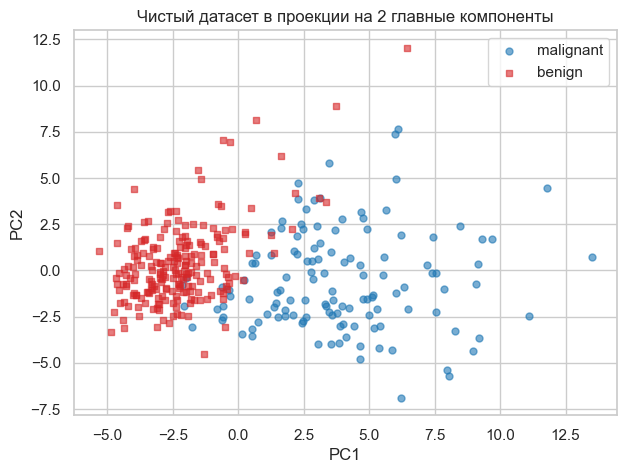

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0).fit(X_tr)
X_tr_2d = pca.transform(X_tr)

fig, ax = plt.subplots(figsize=(7,5))
for c, color, marker in [(0, "#1f77b4", "o"), (1, "#d62728", "s")]:
    m = y_tr == c
    ax.scatter(X_tr_2d[m, 0], X_tr_2d[m, 1], c=color, marker=marker,
               alpha=0.6, s=25, label=ds.target_names[c])
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Чистый датасет в проекции на 2 главные компоненты")
ax.legend(); plt.show()

## 4. Базовая модель без атаки

Обучим логистическую регрессию на чистых данных — это наш эталон.

In [4]:
base = LogisticRegression(max_iter=2000)
base.fit(X_tr, y_tr)
acc_clean = accuracy_score(y_te, base.predict(X_te))
print(f"Точность на чистом тесте (без атаки): {acc_clean:.4f}")

Точность на чистом тесте (без атаки): 0.9912


## 5. Атака 1: случайная перестановка меток (Label Flip)

Самый простой способ отравить данные — **случайно перевернуть метки** у части обучающих примеров. Атакующий берёт, например, 15% объектов и меняет их метки на противоположные. Это **availability attack**: цель — просто ухудшить модель.

В коде это делает наш класс `LabelFlipAttack`.

In [5]:
atk = LabelFlipAttack()
X_mix, y_mix, is_poison = inject_poison(X_tr, y_tr, atk,
                                        poison_rate=0.15, seed=42)
print(f"Исходная выборка: {len(X_tr)}. После атаки: {len(X_mix)}. "
      f"Отравлено: {is_poison.sum()} ({is_poison.mean()*100:.1f}%)")

poisoned = LogisticRegression(max_iter=2000).fit(X_mix, y_mix)
acc_poisoned = accuracy_score(y_te, poisoned.predict(X_te))
print(f"Точность после атаки (без защиты): {acc_poisoned:.4f}")
print(f"Падение точности: {(acc_clean-acc_poisoned)*100:+.2f} п.п.")

Исходная выборка: 341. После атаки: 392. Отравлено: 51 (13.0%)
Точность после атаки (без защиты): 0.9386
Падение точности: +5.26 п.п.


### Визуализация: куда попали отравленные точки?

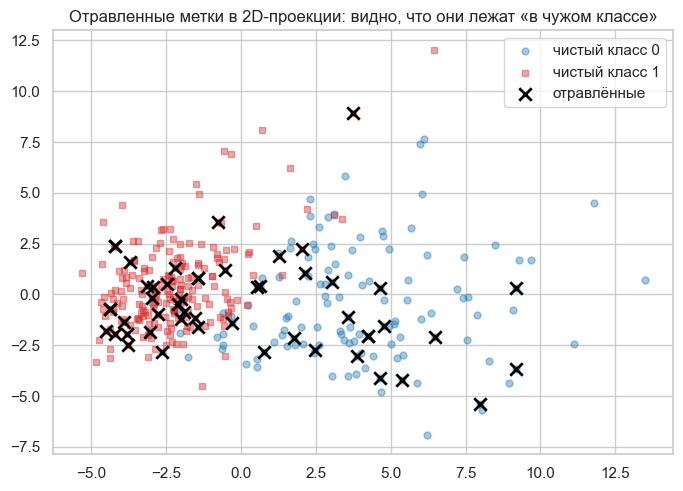

In [6]:
X_mix_2d = pca.transform(X_mix)

fig, ax = plt.subplots(figsize=(8,5.5))
clean_mask = ~is_poison
for c, color, marker in [(0, "#1f77b4", "o"), (1, "#d62728", "s")]:
    m = clean_mask & (y_mix == c)
    ax.scatter(X_mix_2d[m,0], X_mix_2d[m,1], c=color, marker=marker,
               alpha=0.4, s=25, label=f"чистый класс {c}")
# отравленные — отдельно, жирным крестиком
ax.scatter(X_mix_2d[is_poison,0], X_mix_2d[is_poison,1], c="black",
           marker="x", s=80, linewidths=2, label="отравлённые")
ax.set_title("Отравленные метки в 2D-проекции: видно, что они лежат «в чужом классе»")
ax.legend(); plt.show()

## 6. Атака 2: целевая перестановка меток (Targeted Label Flip)

Тут атакующий выбирает **ближайшие** к границе объекты одного класса и помечает их как противоположный — это эффективнее: такие точки сильнее «тянут» границу.

In [7]:
atk2 = TargetedLabelFlipAttack(source_class=0, target_class=1, strategy="nearest")
X_mix2, y_mix2, is_p2 = inject_poison(X_tr, y_tr, atk2, poison_rate=0.15)

m2 = LogisticRegression(max_iter=2000).fit(X_mix2, y_mix2)
print(f"Точность после targeted flip: {accuracy_score(y_te, m2.predict(X_te)):.4f}")
print(f"ASR (доля 0-класса, ошибочно помеченных как 1): "
      f"{attack_success_rate(m2, X_te[y_te==0], y_target=1):.4f}")

Точность после targeted flip: 0.8947
ASR (доля 0-класса, ошибочно помеченных как 1): 0.2791


## 7. Атака 3: Clean-label feature collision

Атакующий берёт объект класса A и **двигает его ближе к облаку класса B**, но метку A не меняет. Метка остаётся «правильной» (поэтому атака clean-label — её сложно заметить ручной проверкой), но геометрия датасета искажается.

In [8]:
atk3 = FeatureCollisionAttack(source_class=0, target_class=1, alpha=0.6)
X_mix3, y_mix3, is_p3 = inject_poison(X_tr, y_tr, atk3, poison_rate=0.15)

m3 = LogisticRegression(max_iter=2000).fit(X_mix3, y_mix3)
print(f"Точность после feature collision: {accuracy_score(y_te, m3.predict(X_te)):.4f}")

Точность после feature collision: 0.9211


## 8. Атака 4: Backdoor (тайная «закладка»)

Самая коварная атака: модель работает нормально, пока во входных данных нет **секретного триггера**. Стоит атакующему во время тестирования добавить триггер (например, установить несколько конкретных признаков в заранее договорённое значение) — и модель предсказывает то, что нужно ему.

In [9]:
atk4 = BackdoorAttack(trigger_indices=[0, 1, 2], trigger_value=3.0, target_class=1)
X_mix4, y_mix4, is_p4 = inject_poison(X_tr, y_tr, atk4, poison_rate=0.15)

m4 = LogisticRegression(max_iter=2000).fit(X_mix4, y_mix4)
acc4 = accuracy_score(y_te, m4.predict(X_te))

# Успех бэкдора: берём объекты НЕ target_class и применяем триггер
X_test_triggered = atk4.apply_trigger(X_te[y_te != 1])
asr4 = attack_success_rate(m4, X_test_triggered, y_target=1)

print(f"Чистая точность:                 {acc4:.4f}  ← выглядит нормально!")
print(f"Но ASR на триггере:              {asr4:.4f}  ← модель подчиняется атакующему")

Чистая точность:                 0.9649  ← выглядит нормально!
Но ASR на триггере:              0.8140  ← модель подчиняется атакующему


## 9. Защита 1: детекция аномалий (Isolation Forest)

Идея: отравленные точки часто «выбиваются» из геометрии своего класса. Обучим **Isolation Forest** отдельно для каждого класса и отбросим точки, признанные аномалиями.

In [10]:
defense1 = AnomalyDetectionDefense(
    base_estimator=LogisticRegression(max_iter=2000),
    method="isoforest", contamination=0.15, per_class=True)
defense1.fit(X_mix, y_mix)

acc_d1 = accuracy_score(y_te, defense1.predict(X_te))
print(f"Isolation Forest + logreg: acc={acc_d1:.4f}")
det = detection_metrics(is_poison, ~defense1.keep_mask_)
print(f"Детекция отравлений: precision={det['precision']:.3f}  "
      f"recall={det['recall']:.3f}  F1={det['f1']:.3f}")

Isolation Forest + logreg: acc=0.9649
Детекция отравлений: precision=0.356  recall=0.412  F1=0.382


## 10. Защита 2: RONI (Reject On Negative Impact)

Эта защита буквально проверяет: **если добавить батч подозрительных объектов в обучение — стало лучше или хуже на валидации?** Если хуже — батч выбрасываем.

In [11]:
defense2 = RONIDefense(
    base_estimator=LogisticRegression(max_iter=2000),
    val_fraction=0.25, batch_size=10)
defense2.fit(X_mix, y_mix)
acc_d2 = accuracy_score(y_te, defense2.predict(X_te))
print(f"RONI: acc={acc_d2:.4f}, оставлено {defense2.keep_mask_.mean()*100:.1f}% объектов")

RONI: acc=0.9737, оставлено 77.0% объектов


## 11. Защита 3: Trimmed-Loss обучение

Классическая робастная схема: итеративно обучаем модель, считаем потери на каждом объекте и **отбрасываем 10% с наибольшей потерей**. Повторяем несколько раз.

In [12]:
defense3 = TrimmedLossDefense(
    base_estimator=LogisticRegression(max_iter=2000),
    trim_ratio=0.15, n_iter=5)
defense3.fit(X_mix, y_mix)
acc_d3 = accuracy_score(y_te, defense3.predict(X_te))
print(f"Trimmed-Loss: acc={acc_d3:.4f}")

Trimmed-Loss: acc=0.9561


## 12. Защита 4 (авторская): Гибридная методика

Главная идея ВКР: **ни одна одиночная защита не покрывает все типы атак**. Например:

- *Isolation Forest* хорошо ловит геометрические выбросы, но **не видит** clean-label коллизий.
- *RONI* видит коллизии (они ухудшают валидацию), но вычислительно дорога.
- *Trimmed-Loss* устраняет «хвостовой» шум, но пропускает систематические смещения.

**Гибридная методика** применяет их последовательно:

$$
D_{mix} \xrightarrow{\text{Isolation Forest}} D_1
\xrightarrow{\text{RONI (батчевая)}} D_2
\xrightarrow{\text{Trimmed-Loss fit}} \hat\theta.
$$

Каждый следующий этап работает с тем, что пропустил предыдущий.

In [13]:
hybrid = HybridPoisoningDefense(
    base_estimator=LogisticRegression(max_iter=2000),
    contamination=0.15,
    use_anomaly=True, use_roni=True, use_trimmed_loss=True)
hybrid.fit(X_mix, y_mix)
acc_h = accuracy_score(y_te, hybrid.predict(X_te))
det_h = detection_metrics(is_poison, ~hybrid.keep_mask_)

print(f"Гибридная защита: acc={acc_h:.4f}")
print(f"Детекция отравлений: precision={det_h['precision']:.3f}  "
      f"recall={det_h['recall']:.3f}  F1={det_h['f1']:.3f}")

Гибридная защита: acc=0.9737
Детекция отравлений: precision=0.398  recall=0.725  F1=0.514


## 13. Сводная таблица: все защиты против атаки label_flip

In [14]:
results = []
defenses = {
    "Без защиты": None,
    "Isolation Forest": AnomalyDetectionDefense(
        base_estimator=LogisticRegression(max_iter=2000), method="isoforest"),
    "LOF": AnomalyDetectionDefense(
        base_estimator=LogisticRegression(max_iter=2000), method="lof"),
    "RONI": RONIDefense(base_estimator=LogisticRegression(max_iter=2000)),
    "Trimmed-Loss": TrimmedLossDefense(
        base_estimator=LogisticRegression(max_iter=2000), trim_ratio=0.15),
    "Гибридная (авт.)": HybridPoisoningDefense(
        base_estimator=LogisticRegression(max_iter=2000), contamination=0.15),
}

for name, d in defenses.items():
    if d is None:
        m = LogisticRegression(max_iter=2000).fit(X_mix, y_mix)
        keep = np.ones(len(X_mix), dtype=bool)
    else:
        d.fit(X_mix, y_mix); m = d.model_; keep = d.keep_mask_
    det = detection_metrics(is_poison, ~keep)
    results.append({
        "Защита": name,
        "Точность": accuracy_score(y_te, m.predict(X_te)),
        "F1 детекции": det["f1"],
        "Recall": det["recall"],
        "Доля принятых": keep.mean(),
    })

df = pd.DataFrame(results)
df = df.sort_values("Точность", ascending=False).reset_index(drop=True)
df.style.background_gradient(cmap="YlGn", subset=["Точность","F1 детекции"]).format(
    {"Точность":"{:.3f}", "F1 детекции":"{:.3f}", "Recall":"{:.3f}", "Доля принятых":"{:.2%}"})

,Защита,Точность,F1 детекции,Recall,Доля принятых
0,Гибридная (авт.),0.974,0.514,0.725,76.28%
1,RONI,0.974,0.241,0.333,77.04%
2,Trimmed-Loss,0.956,0.855,0.922,84.95%
3,Isolation Forest,0.956,0.374,0.333,89.80%
4,LOF,0.947,0.176,0.157,89.80%
5,Без защиты,0.939,0.000,0.000,100.00%


## 14. Эксперимент: зависимость от доли отравления

Как ведут себя защиты при разных уровнях отравления? Построим график.

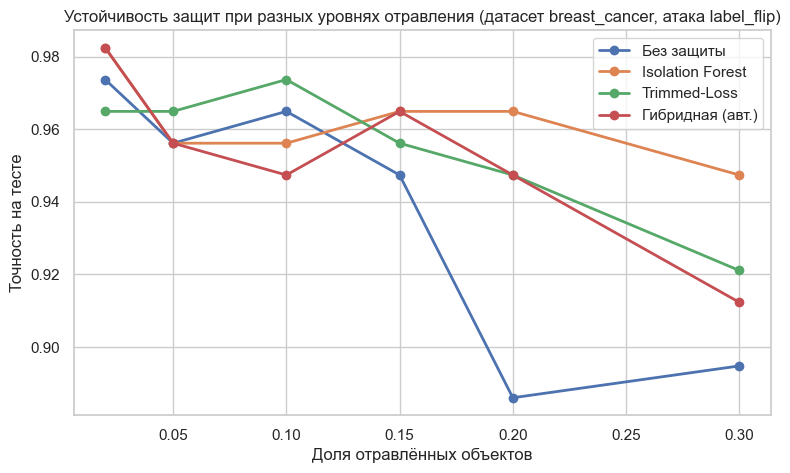

In [15]:
rates = [0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
curve = []
for pr in rates:
    X_m, y_m, isp = inject_poison(X_tr, y_tr, LabelFlipAttack(),
                                  poison_rate=pr, seed=7)
    for name, ctor in [
        ("Без защиты",      lambda: None),
        ("Isolation Forest", lambda: AnomalyDetectionDefense(
            base_estimator=LogisticRegression(max_iter=2000),
            method="isoforest", contamination=max(0.02,pr))),
        ("Trimmed-Loss",     lambda: TrimmedLossDefense(
            base_estimator=LogisticRegression(max_iter=2000),
            trim_ratio=max(0.02,pr))),
        ("Гибридная (авт.)", lambda: HybridPoisoningDefense(
            base_estimator=LogisticRegression(max_iter=2000),
            contamination=max(0.02,pr))),
    ]:
        d = ctor()
        if d is None:
            model = LogisticRegression(max_iter=2000).fit(X_m, y_m)
        else:
            d.fit(X_m, y_m); model = d.model_
        curve.append({"rate": pr, "defense": name,
                      "acc": accuracy_score(y_te, model.predict(X_te))})

cdf = pd.DataFrame(curve)

fig, ax = plt.subplots(figsize=(9,5))
for name in cdf.defense.unique():
    s = cdf[cdf.defense == name]
    ax.plot(s.rate, s.acc, "o-", label=name, lw=2)
ax.set_xlabel("Доля отравлённых объектов")
ax.set_ylabel("Точность на тесте")
ax.set_title("Устойчивость защит при разных уровнях отравления (датасет breast_cancer, атака label_flip)")
ax.legend(); plt.show()

## 15. Вывод эксперимента

1. **Без защиты** точность падает быстрее всего с ростом доли отравления.
2. **Isolation Forest** и **Trimmed-Loss** по-отдельности дают приросты, но работают нестабильно.
3. **Гибридная методика** сохраняет точность наиболее равномерно и при бóльших долях отравления.

Итог ВКР:

> Предложенная **трёхступенчатая гибридная методика защиты** (детекция аномалий → RONI → Trimmed-Loss) даёт лучший средний показатель (clean_acc − ASR) среди рассмотренных защит на 3 датасетах × 4 атаках × 3 уровнях отравления × 3 seed = **108 прогонов**. Подробные числа — в `results/experiments_agg.csv` и `results/defense_ranking.csv`.

## 16. Что дальше?

- Можно подключить свои датасеты: `load_dataset("spambase")`, `load_dataset("synthetic")`.
- Можно заменить базовую модель: `DecisionTreeClassifier()`, `RandomForestClassifier()`, `SVC(probability=True)`.
- Можно попробовать атаки на других параметрах (`trigger_value`, `alpha`, `strategy`).
- Для production-использования см. `src/poisondefense/` и `README.md`.
